**Classification Algorithm -> Logistic Regression and Machine Learning Specifics**

In [9]:
import numpy as np
import random as rand
import matplotlib.pyplot as plt
import sklearn
import math

**Problem Statement**

Classification is another type of prediction problem. Unlike Regression, it has a finite set of output values. When you use a regression model like linear regression for classification purposes, it can sometimes work if you impose a threshold to convert continuous values to classes, but if there are new datapoints that are in extreme values, that can shift the decision boundary and create a sub-optimal model. For this reason we need classification algorithm specialized in this

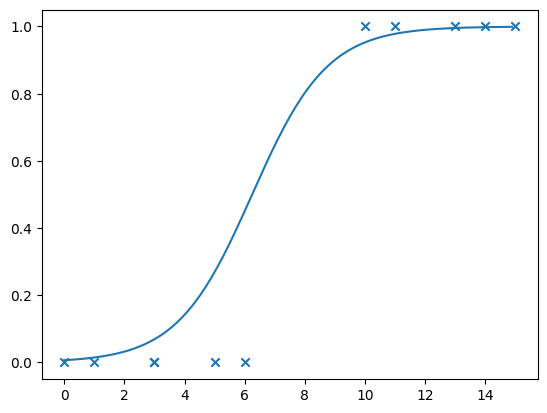

In [24]:
# Logistic Regression Curve(Sigmoid Curve) Visualization

# Data points
X_train = np.array([0, 1, 3, 6, 3, 5, 10, 15, 13, 14, 11])
y_train = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

w = 0.8
b = -5

# Logistic Regression Model Definition
def f_wb_logistic(x, w, b):
    z = np.dot(x, w) + b
    # pass z into sigmoid function
    return (1/(1+ np.exp(-z)))

# Create plotting values
x_s = np.arange(0,15,0.1)
output_logistic = []
for x in x_s:
    output_logistic.append(f_wb_logistic(x, w, b))

plt.scatter(X_train, y_train, marker="x")
plt.plot(x_s, output_logistic)
plt.show()

**Decision Boundary**
- The decision boundary is set based on some threshold value (eg. 0.5)
- Any value above or below the threshold predicted by the continuous output of the sigmoid gets converted into a binary classification
- For threshold 0.5, the decision boundary is when z = 0. This is when w*x + b = 0. With different x's, w's, and b's can dictate the position of the decision boundary
- For more compelx boundaries we need different features(x^2, x^3) to make circular, and other shaped decision boundaries based on the data we are trying to predict/fit

**Cost Function For Logistic Regression**

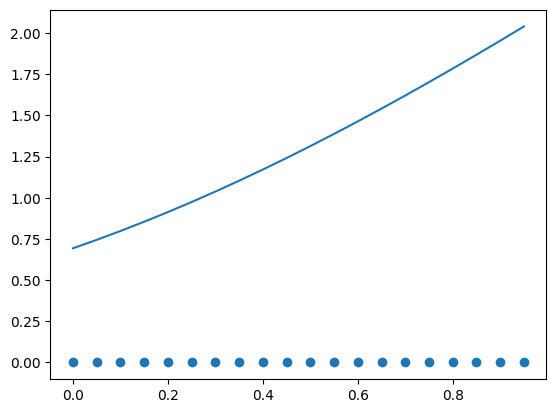

In [47]:
# Squared Error Cost Function does not work for Logistic regression because it is not convex

# Full version
def L_wb_logistic(x, y, w, b):
    prediction = f_wb_logistic(x, w, b)
    loss = 0
    if y == 1:
        loss = -np.log(prediction)
    else:
        loss = -np.log(1-prediction)
    return loss

x_s = np.arange(0,1, 0.05)
y_0s = np.zeros(20)
y_1s = np.ones(20)

loss_0s = []
loss_1s = []

for i in range(len(x_s)):
    loss_0s.append(L_wb_logistic(x_s[i], y_0s[i], 2, 0))
    loss_1s.append(L_wb_logistic(x_s[i], y_1s[i], 2, 0))

plt.scatter(x_s, y_0s)
#plt.scatter(x_s, y_1s)
plt.plot(x_s, loss_0s)
#plt.plot(x_s, loss_1s)
plt.show()

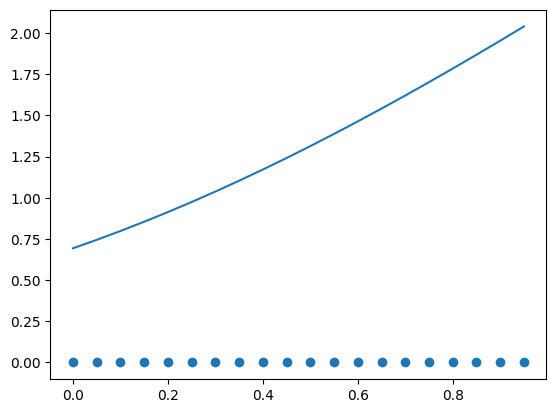

0.3668667864055174


In [50]:
# More Simplified and General Binary Cost Function
# Cost Function Definition

def L_wb_logistic_simple(x, y, w, b):
    return ((-y*np.log(f_wb_logistic(x,w,b))) - (1-y)*(np.log(1-(f_wb_logistic(x,w,b)))))

def J_wb_logistic(x, y, w, b):
    m = len(x)
    loss = 0
    for i in range(m):
        loss += L_wb_logistic_simple(x[i], y[i], w, b)
    return loss*(1/m)

x_s = np.arange(0,1, 0.05)
y_0s = np.zeros(20)
y_1s = np.ones(20)

loss_0s = []
loss_1s = []

for i in range(len(x_s)):
    loss_0s.append(L_wb_logistic_simple(x_s[i], y_0s[i], 2, 0))
    loss_1s.append(L_wb_logistic_simple(x_s[i], y_1s[i], 2, 0))

plt.scatter(x_s, y_0s)
#plt.scatter(x_s, y_1s)
plt.plot(x_s, loss_0s)
#plt.plot(x_s, loss_1s)
plt.show()

X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])

w_tmp = np.array([1,1])
b_tmp = -3
print(J_wb_logistic(X_train, y_train, w_tmp, b_tmp))

**Gradient Descent With Logistic Cost Function + full Training Implementation of Logistic Regression**

Epoch 0 | Loss = 4.992523392077746 | w = [4.99500023 4.99500023] b = -0.004999772923521262
Epoch 100 | Loss = 4.242683358560863 | w = [4.49505337 4.49505335] b = -0.5049466646714564
Epoch 200 | Loss = 3.493400278933854 | w = [3.99529167 3.9952915 ] b = -1.0047086851650315
Epoch 300 | Loss = 2.7466052084519443 | w = [3.49635883 3.49635723] b = -1.50364461512581
Epoch 400 | Loss = 2.010734900078532 | w = [3.00109193 3.00107695] b = -1.9989410601594229
Epoch 500 | Loss = 1.3192575692485065 | w = [2.52112148 2.52098729] b = -2.479181990770621
Epoch 600 | Loss = 0.7655669346575509 | w = [2.09293127 2.09190417] b = -2.9094731423003086
Epoch 700 | Loss = 0.44936699936927804 | w = [1.77517326 1.76973606] b = -3.238105232529639
Epoch 800 | Loss = 0.327586616722227 | w = [1.59119319 1.57364828] b = -3.4538090815770066
Epoch 900 | Loss = 0.29165950258892875 | w = [1.51134953 1.47407368] b = -3.58955285914138
Epoch 1000 | Loss = 0.2806184725222779 | w = [1.49123605 1.43086916] b = -3.6814931839727

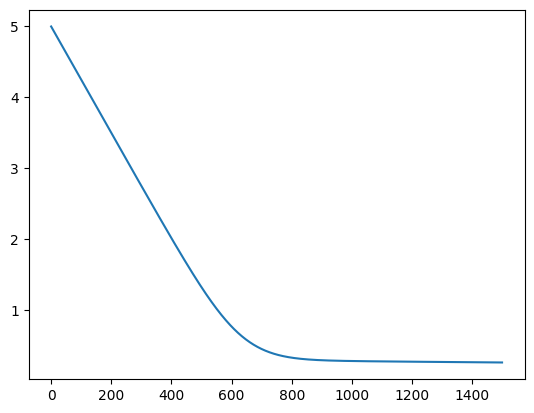

In [75]:
# Gradient Computation

def gradient(sel, x, y, w, b):
    if sel == 'w':
        return (1/len(x)) * np.dot(x.T, (f_wb_logistic(x,w,b) - y))
    else:
        return (1/len(x)) * np.sum(f_wb_logistic(x,w,b) - y)

def gradient_descent(x, y, w, b):
    alpha = 1e-2
    tmp_w = w - alpha*gradient('w', x, y, w, b)
    tmp_b = b - alpha*gradient('b', x, y, w, b)
    w = tmp_w
    b = tmp_b

    return w, b

epoch = 1500
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])

w = np.array([5,5])
b = 0

x_s = []
loss_s = []
for i in range(epoch):
    x_s.append(i)
    w, b = gradient_descent(X_train, y_train, w, b)
    loss_s.append(J_wb_logistic(X_train,y_train,w,b))
    if i % 100 == 0:
        print(f"Epoch {i} | Loss = {J_wb_logistic(X_train,y_train,w,b)} | w = {w} b = {b}")

plt.plot(x_s, loss_s)
plt.show()

**Overfitting & Underfitting**

Overfitting is when the model is too complex and tries to perfectly fit the training examples. It leads to the model not generalizing well and performs poorly on new data.

To address overfitting we can do the following:
- Add more training examples. This will make is so that the model cannot add complex wavy features to the model inbetween training examples. With more data that also provides a better estimate of the new data and is more practical to test on
- Use fewer more targetted features. This makes it so that the features which are more complex they would ne replaced and not included in the model
- Regularization: Where we decrease the magnitude of the different weights to the features such that they do not have as big a contribution on the model and reduce overfitting. 

Underfitting is when the model is too simplistic for the problem and does not fit even the training data well. The cost does not converge well in the training stage.